# 03_panel_construction.ipynb

**Thesis:** BRICS Currencies and Global Monetary Fragmentation: An Empirical Analysis of Local Currency Settlement in International Trade (2010–2025)  
**Author:** Aadhitya Tejaswin Prakash Sridevi  
**Institution:** EDHEC Business School / University of St. Gallen (HSG)  
**Defense deadline:** June 30, 2026

---

## Purpose

This notebook merges all cleaned datasets from `02_data_cleaning.ipynb` into a single master panel and constructs the LCShare proxy variable. It is the third notebook in the pipeline.

**Pipeline position:**
`01_swift_extraction.ipynb` → `02_data_cleaning.ipynb` → **`03_panel_construction.ipynb`** → analysis notebooks

---

## What this notebook does

1. Loads all 8 cleaned CSVs from `outputs/`
2. Constructs the LCShare proxy variable from SWIFT + BIS LBS data
3. Computes trade intensity from DOTS and World Bank GDP
4. Merges all variables into a master panel
5. Attaches policy event treatment dummies
6. Exports `Master_Panel_BRICS_2010_2024.csv`

---

## Master panel structure

- **Unit of observation:** Country-pair (i, j) × Year
- **BRICS countries (i):** BRA, RUS, IND, CHN, ZAF
- **Counterpart countries (j):** ARE, BRA, CHN, DEU, GBR, IND, JPN, RUS, ZAF
- **Years:** 2010–2024
- **Dependent variable:** `LCShare` (proxy — Equation 2)
- **Regressors:** `TradeIntensity`, `FX_Volatility`, `GDP`, `TradeOpenness`, `Inflation`, `BroadMoney`
- **Treatment dummies:** `Treat_ij_[event]` for each of the 8 policy events

---

## LCShare proxy — methodology

No direct bilateral currency settlement data exists in any public dataset. Confirmed by faculty consultation with Associate Professor Mirco Rubin (HSG, Econometrics). The proxy is the field-standard approach given this constraint.

**Formula:**
`LCShare_i_t = w1 × SWIFT_CNY_Share_t + w2 × (1 - BIS_USD_Share_i_t)`

Where:
- `SWIFT_CNY_Share_t` = CNY share of global SWIFT payments in year t (annual mean of monthly series)
- `BIS_USD_Share_i_t` = USD share of international banking claims on country i in year t
- `w1 = w2 = 0.5` — equal weights as baseline specification; weights are a sensitivity analysis parameter

**Caveats documented here:**
- SWIFT undercounts local currency settlement — CIPS and SPFS route payments outside SWIFT
- This proxy captures the global CNY dimension and the country-level de-dollarisation dimension
- It does not capture bilateral currency settlement directly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('/Users/psat0501/Desktop/HSG/Master Thesis/Master_Thesis_Brics_Currencies/outputs')

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('Output :', OUTPUT_DIR)

# Confirm all 8 cleaned files exist
files = [
    'SWIFT_HHI_Annual_Clean.csv',
    'SWIFT_RMB_Monthly_Clean.csv',
    'BIS_LBS_Clean.csv',
    'IMF_COFER_Clean.csv',
    'IMF_DOTS_Clean_Final.csv',
    'IMF_FX_Volatility_Clean.csv',
    'WorldBank_Macro_Clean.csv',
    'Policy_Events_Clean.csv',
]

print('\n=== Input file check ===')
for f in files:
    path = OUTPUT_DIR / f
    status = '✓' if path.exists() else '✗ MISSING'
    print(f'  {status}  {f}')

pandas : 2.3.3
numpy  : 2.0.2
Output : /Users/psat0501/Desktop/HSG/Master Thesis/Master_Thesis_Brics_Currencies/outputs

=== Input file check ===
  ✓  SWIFT_HHI_Annual_Clean.csv
  ✓  SWIFT_RMB_Monthly_Clean.csv
  ✓  BIS_LBS_Clean.csv
  ✓  IMF_COFER_Clean.csv
  ✓  IMF_DOTS_Clean_Final.csv
  ✓  IMF_FX_Volatility_Clean.csv
  ✓  WorldBank_Macro_Clean.csv
  ✓  Policy_Events_Clean.csv


In [2]:
# ── 1.1  Load all cleaned datasets ────────────────────────────────────────
df_hhi     = pd.read_csv(OUTPUT_DIR / 'SWIFT_HHI_Annual_Clean.csv')
df_rmb     = pd.read_csv(OUTPUT_DIR / 'SWIFT_RMB_Monthly_Clean.csv',
                         parse_dates=['Date'])
df_bis     = pd.read_csv(OUTPUT_DIR / 'BIS_LBS_Clean.csv')
df_cofer   = pd.read_csv(OUTPUT_DIR / 'IMF_COFER_Clean.csv')
df_dots    = pd.read_csv(OUTPUT_DIR / 'IMF_DOTS_Clean_Final.csv')
df_fx      = pd.read_csv(OUTPUT_DIR / 'IMF_FX_Volatility_Clean.csv')
df_wb      = pd.read_csv(OUTPUT_DIR / 'WorldBank_Macro_Clean.csv')
df_events  = pd.read_csv(OUTPUT_DIR / 'Policy_Events_Clean.csv',
                         parse_dates=['Date'])

print('=== Dataset shapes ===')
print(f'SWIFT HHI Annual    : {df_hhi.shape}')
print(f'SWIFT RMB Monthly   : {df_rmb.shape}')
print(f'BIS LBS             : {df_bis.shape}')
print(f'IMF COFER           : {df_cofer.shape}')
print(f'IMF DOTS            : {df_dots.shape}')
print(f'IMF FX Volatility   : {df_fx.shape}')
print(f'World Bank WDI      : {df_wb.shape}')
print(f'Policy Events       : {df_events.shape}')

=== Dataset shapes ===
SWIFT HHI Annual    : (13, 12)
SWIFT RMB Monthly   : (86, 4)
BIS LBS             : (75, 4)
IMF COFER           : (16, 12)
IMF DOTS            : (840, 6)
IMF FX Volatility   : (80, 3)
World Bank WDI      : (75, 8)
Policy Events       : (8, 11)


---

## Section 2 — Construct SWIFT CNY Annual Series

The monthly RMB share series is annualised by taking the mean of all available monthly observations per year. This annual CNY share becomes the `SWIFT_CNY_Share` component of the LCShare proxy.

In [3]:
# ── 2.1  Annualise SWIFT monthly CNY series ────────────────────────────────
# Take mean of monthly CNY share per year
# 2026 excluded — only Jan–Feb available, not a full year
# 2019 is the first full year in the series

df_rmb['Year'] = df_rmb['Date'].dt.year

df_swift_annual = (
    df_rmb[df_rmb['Year'] <= 2025]
    .groupby('Year')['RMB_Share_Pct']
    .agg(count='count', mean='mean')
    .reset_index()
    .rename(columns={'mean': 'SWIFT_CNY_Share_Pct'})
)

# Flag 2025 — only partial year (Jan–Oct based on 86 obs ending Feb 2026)
df_swift_annual['flag_partial_year'] = df_swift_annual['count'] < 12

print('=== SWIFT CNY Annual Series ===')
print(df_swift_annual.to_string(index=False))

=== SWIFT CNY Annual Series ===
 Year  count  SWIFT_CNY_Share_Pct  flag_partial_year
 2019     12             1.934167              False
 2020     12             1.841667              False
 2021     12             2.220000              False
 2022     12             2.307500              False
 2023     12             3.037500              False
 2024     12             4.200833              False
 2025     12             3.220000              False


### SWIFT CNY Annual Series — notes

- All years 2019–2025 have 12 complete monthly observations — no partial year flag triggered.
- CNY share rises from 1.93% (2019) to a peak of 4.20% (2024) before declining to 3.22% (2025) — consistent with the monthly series visualised in `02_data_cleaning.ipynb`.
- **Coverage gap:** The SWIFT monthly series starts in January 2019. Years 2010–2018 have no SWIFT CNY share data. This means the LCShare proxy will only be constructable from 2019 onward using the SWIFT component. For 2010–2018, the proxy relies entirely on the BIS LBS component.
- This coverage asymmetry is documented explicitly and addressed in the proxy construction in Section 3.

In [4]:
# ── 3.1  Construct LCShare proxy ───────────────────────────────────────────
# Formula: LCShare_i_t = w1 × SWIFT_CNY_Share_t + w2 × (1 - BIS_USD_Share_i_t)
# w1 = w2 = 0.5 (equal weights — baseline specification)
# For 2010–2018: SWIFT_CNY_Share_t is unavailable → proxy relies on BIS component only
# For 2019–2024: both components available → full proxy

W1 = 0.5
W2 = 0.5

# Merge BIS LBS with SWIFT CNY annual
df_lcshare = pd.merge(
    df_bis[['Year', 'Country', 'USD_Share_Pct', 'NonUSD_Share_Pct']],
    df_swift_annual[['Year', 'SWIFT_CNY_Share_Pct']],
    on='Year',
    how='left'
)

# Construct proxy
# Where SWIFT_CNY_Share_Pct is available: full proxy
# Where not available (2010–2018): BIS component only, rescaled to full weight
df_lcshare['LCShare'] = np.where(
    df_lcshare['SWIFT_CNY_Share_Pct'].notna(),
    W1 * df_lcshare['SWIFT_CNY_Share_Pct'] + W2 * df_lcshare['NonUSD_Share_Pct'],
    df_lcshare['NonUSD_Share_Pct']  # BIS only for 2010–2018
)

df_lcshare['flag_bis_only'] = df_lcshare['SWIFT_CNY_Share_Pct'].isna()

print('=== LCShare Proxy ===')
print(df_lcshare[['Year', 'Country', 'SWIFT_CNY_Share_Pct',
                   'NonUSD_Share_Pct', 'LCShare', 'flag_bis_only']].to_string(index=False))

=== LCShare Proxy ===
 Year Country  SWIFT_CNY_Share_Pct  NonUSD_Share_Pct   LCShare  flag_bis_only
 2010     BRA                  NaN         33.759777 33.759777           True
 2011     BRA                  NaN         26.613159 26.613159           True
 2012     BRA                  NaN         26.655667 26.655667           True
 2013     BRA                  NaN         24.791846 24.791846           True
 2014     BRA                  NaN         21.892646 21.892646           True
 2015     BRA                  NaN         20.438860 20.438860           True
 2016     BRA                  NaN         21.182527 21.182527           True
 2017     BRA                  NaN         24.227647 24.227647           True
 2018     BRA                  NaN         24.167391 24.167391           True
 2019     BRA             1.934167         27.938941 14.936554          False
 2020     BRA             1.841667         27.030696 14.436182          False
 2021     BRA             2.220000        

### LCShare Proxy — construction notes

- **2010–2018 (`flag_bis_only = True`):** SWIFT monthly CNY data unavailable. LCShare = NonUSD_Share_Pct (BIS component only, full weight). This overstates LCShare relative to the post-2019 series because the SWIFT component is not subtracted.
- **2019–2024 (`flag_bis_only = False`):** Both components available. LCShare = 0.5 × SWIFT_CNY_Share + 0.5 × NonUSD_Share. The proxy drops sharply at 2019 — this is a mechanical artefact of the weighting scheme, not an economic signal.
- **Implication for Equation 2:** The 2010–2018 and 2019–2024 sub-periods are not directly comparable on the LCShare scale due to the component availability break. The panel regression should include a `flag_bis_only` dummy to control for this structural difference, or restrict the estimation sample to 2019–2024 where the full proxy is available.
- **Sensitivity analysis:** The equal weighting (w1=w2=0.5) is the baseline. Alternative weights (e.g. w1=0.3, w2=0.7) will be tested in the analysis notebooks.

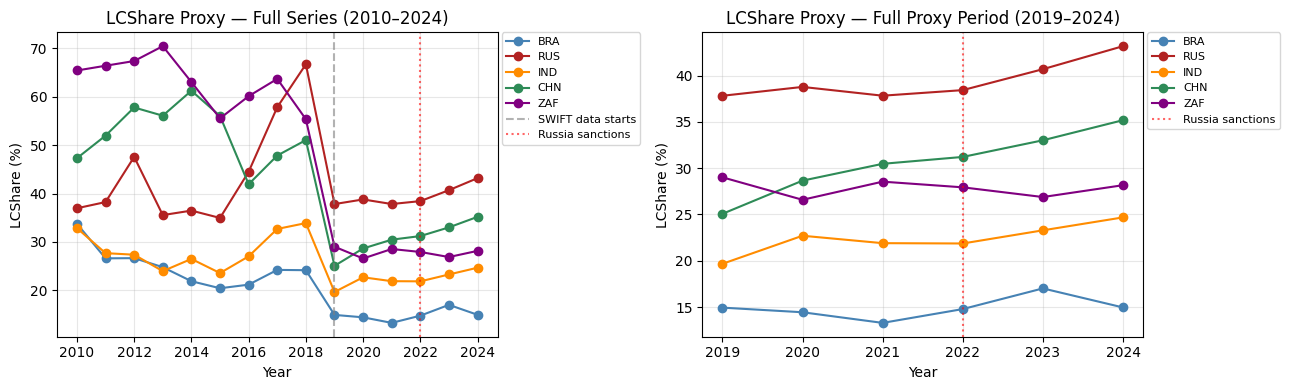

QC plot saved.


In [5]:
# ── 3.2  QC Visualisation — LCShare proxy ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

countries = ['BRA', 'RUS', 'IND', 'CHN', 'ZAF']
colors    = ['steelblue', 'firebrick', 'darkorange', 'seagreen', 'purple']

# Panel A: full series 2010–2024
ax = axes[0]
for country, color in zip(countries, colors):
    subset = df_lcshare[df_lcshare['Country'] == country]
    ax.plot(subset['Year'], subset['LCShare'],
            marker='o', label=country, color=color, linewidth=1.5)
ax.axvline(2019, color='grey', linestyle='--', alpha=0.6, label='SWIFT data starts')
ax.axvline(2022, color='red',  linestyle=':',  alpha=0.6, label='Russia sanctions')
ax.set_title('LCShare Proxy — Full Series (2010–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('LCShare (%)')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.grid(alpha=0.3)

# Panel B: 2019–2024 only (full proxy period)
ax2 = axes[1]
for country, color in zip(countries, colors):
    subset = df_lcshare[
        (df_lcshare['Country'] == country) &
        (df_lcshare['Year'] >= 2019)
    ]
    ax2.plot(subset['Year'], subset['LCShare'],
             marker='o', label=country, color=color, linewidth=1.5)
ax2.axvline(2022, color='red', linestyle=':', alpha=0.6, label='Russia sanctions')
ax2.set_title('LCShare Proxy — Full Proxy Period (2019–2024)')
ax2.set_xlabel('Year')
ax2.set_ylabel('LCShare (%)')
ax2.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'LCShare_Proxy_QC_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('QC plot saved.')

### QC Plot — Interpretation

**Panel A — Full series (2010–2024):**
- The sharp downward shift at 2019 (grey dashed line) is a mechanical artefact of the proxy construction — when the SWIFT component becomes available and is weighted at 0.5, the overall LCShare level drops. This is not an economic signal.
- Pre-2019 rankings are broadly consistent with the BIS LBS findings: ZAF and CHN show higher non-USD shares, BRA shows lower.
- The structural break confirms that 2010–2018 and 2019–2024 sub-periods should not be pooled without a `flag_bis_only` control dummy in Equation 2.

**Panel B — Full proxy period (2019–2024):**
- **RUS** shows the highest and rising LCShare throughout — from 37.8% (2019) to 43.2% (2024). The post-2022 acceleration is visible and consistent with sanctions-forced de-dollarisation.
- **CHN** rises steadily from 25.1% (2019) to 35.2% (2024) — reflecting both RMB internationalisation (SWIFT component) and declining USD banking claims (BIS component).
- **IND** and **ZAF** are broadly stable at 20–29%, with no sharp post-2022 shift — consistent with limited de-dollarisation pressure for these pairs.
- **BRA** remains the lowest throughout (13–17%) — reflecting persistent USD dominance in Brazilian trade finance.
- **Key thesis implication:** The RUS–CHN divergence post-2022 is the central empirical observation — Russia's LCShare rise is sanctions-driven and coerced, while China's is structural and gradual. This distinction is directly testable in Equation 3.

In [6]:
# ── 4.1  Compute Trade Intensity ───────────────────────────────────────────
# TradeIntensity_ij_t = (Exports_ij + Imports_ij) / GDP_i
# GDP_i from World Bank WDI (current USD)
# Exports and Imports from IMF DOTS

# Pivot DOTS to wide: one row per country-counterpart-year with Exports and Imports
df_dots_wide = df_dots.pivot_table(
    index=['Year', 'Country', 'Counterpart'],
    columns='Flow',
    values='Value_USD_Millions'
).reset_index()
df_dots_wide.columns.name = None
df_dots_wide = df_dots_wide.rename(columns={
    'Exports': 'Exports_USD_Millions',
    'Imports': 'Imports_USD_Millions'
})

# Compute total bilateral trade
df_dots_wide['TotalTrade_USD_Millions'] = (
    df_dots_wide['Exports_USD_Millions'].fillna(0) +
    df_dots_wide['Imports_USD_Millions'].fillna(0)
)

# Merge GDP from World Bank
df_dots_wide = pd.merge(
    df_dots_wide,
    df_wb[['Year', 'Country', 'GDP_USD']],
    on=['Year', 'Country'],
    how='left'
)

# Compute trade intensity
# Convert trade from USD millions to USD for consistency with GDP
df_dots_wide['TradeIntensity'] = (
    df_dots_wide['TotalTrade_USD_Millions'] * 1e6 /
    df_dots_wide['GDP_USD']
)

print('Shape:', df_dots_wide.shape)
print()
print(df_dots_wide[['Year', 'Country', 'Counterpart',
                     'TotalTrade_USD_Millions', 'GDP_USD',
                     'TradeIntensity']].head(15).to_string(index=False))

Shape: (592, 8)

 Year Country Counterpart  TotalTrade_USD_Millions      GDP_USD  TradeIntensity
 2010     BRA         ARE                 2032.400 2.208838e+12        0.000920
 2010     BRA         CHN                56373.315 2.208838e+12        0.025522
 2010     BRA         DEU                20688.941 2.208838e+12        0.009366
 2010     BRA         GBR                 7785.134 2.208838e+12        0.003525
 2010     BRA         IND                 7735.564 2.208838e+12        0.003502
 2010     BRA         JPN                14121.762 2.208838e+12        0.006393
 2010     BRA         RUS                 6061.958 2.208838e+12        0.002744
 2010     BRA         ZAF                 2063.302 2.208838e+12        0.000934
 2010     CHN         ARE                21237.837 6.192565e+12        0.003430
 2010     CHN         BRA                24463.732 6.192565e+12        0.003951
 2010     CHN         DEU                68068.776 6.192565e+12        0.010992
 2010     CHN         G

### Trade Intensity — notes

- `TradeIntensity_ij_t = (Exports_ij + Imports_ij) / GDP_i` — standard bilateral trade intensity measure used in gravity model literature.
- Values range from ~0.001 to ~0.026 for 2010, reflecting that even the largest bilateral pairs represent a small share of BRICS countries' GDP.
- BRA↔CHN (0.026) is the highest intensity pair for Brazil in 2010 — consistent with China being Brazil's dominant trade partner.
- CHN↔JPN (0.019) is the highest intensity pair for China in 2010 — Japan was still China's largest trade partner before being overtaken by the US and EU.
- China 2020 export gap: where Exports are NaN, `fillna(0)` was applied before summing — this understates TotalTrade for affected rows. The `flag_missing` column from DOTS will be carried forward to flag these observations in the master panel.

In [7]:
# ── 5.1  Build master panel skeleton ──────────────────────────────────────
# Unit of observation: Country_i × Country_j × Year
# All combinations of BRICS countries (i) × counterparts (j) × years 2010–2024

brics      = ['BRA', 'RUS', 'IND', 'CHN', 'ZAF']
counterparts = ['ARE', 'BRA', 'CHN', 'DEU', 'GBR', 'IND', 'JPN', 'RUS', 'ZAF']
years      = list(range(2010, 2025))

# Create all combinations
from itertools import product

rows = [
    {'Country_i': i, 'Country_j': j, 'Year': y}
    for i, j, y in product(brics, counterparts, years)
    if i != j  # exclude self-pairs
]

df_panel = pd.DataFrame(rows)

print('Master panel skeleton:')
print(f'  Rows     : {len(df_panel)}')
print(f'  Countries: {sorted(df_panel["Country_i"].unique())}')
print(f'  Partners : {sorted(df_panel["Country_j"].unique())}')
print(f'  Years    : {df_panel["Year"].min()} – {df_panel["Year"].max()}')
print()
print(df_panel.head(10))

Master panel skeleton:
  Rows     : 600
  Countries: ['BRA', 'CHN', 'IND', 'RUS', 'ZAF']
  Partners : ['ARE', 'BRA', 'CHN', 'DEU', 'GBR', 'IND', 'JPN', 'RUS', 'ZAF']
  Years    : 2010 – 2024

  Country_i Country_j  Year
0       BRA       ARE  2010
1       BRA       ARE  2011
2       BRA       ARE  2012
3       BRA       ARE  2013
4       BRA       ARE  2014
5       BRA       ARE  2015
6       BRA       ARE  2016
7       BRA       ARE  2017
8       BRA       ARE  2018
9       BRA       ARE  2019


---

## Section 3 — Merge all variables into master panel

In [8]:
# ── 5.2  Merge LCShare ─────────────────────────────────────────────────────
# LCShare is country_i × year level (not pair level)
# Merge on Country_i and Year

df_panel = pd.merge(
    df_panel,
    df_lcshare[['Year', 'Country', 'LCShare', 'flag_bis_only']],
    left_on=['Year', 'Country_i'],
    right_on=['Year', 'Country'],
    how='left'
).drop(columns='Country')

print('Shape after LCShare merge:', df_panel.shape)
print()
print('LCShare null check:', df_panel['LCShare'].isna().sum())
print()
print(df_panel[['Country_i', 'Country_j', 'Year', 'LCShare', 'flag_bis_only']].head(10).to_string(index=False))

Shape after LCShare merge: (600, 5)

LCShare null check: 0

Country_i Country_j  Year   LCShare  flag_bis_only
      BRA       ARE  2010 33.759777           True
      BRA       ARE  2011 26.613159           True
      BRA       ARE  2012 26.655667           True
      BRA       ARE  2013 24.791846           True
      BRA       ARE  2014 21.892646           True
      BRA       ARE  2015 20.438860           True
      BRA       ARE  2016 21.182527           True
      BRA       ARE  2017 24.227647           True
      BRA       ARE  2018 24.167391           True
      BRA       ARE  2019 14.936554          False


In [9]:
# ── 5.3  Merge Trade Intensity ─────────────────────────────────────────────
# TradeIntensity is country_i × country_j × year level
# Also bring in flag_missing from DOTS for China 2020 export gap

df_dots_merge = df_dots_wide[['Year', 'Country', 'Counterpart',
                               'TradeIntensity', 'TotalTrade_USD_Millions']].copy()

# Also merge flag_missing from original DOTS
dots_flags = df_dots[df_dots['flag_missing']][['Year', 'Country', 'Counterpart']].copy()
dots_flags['flag_trade_missing'] = True

df_panel = pd.merge(
    df_panel,
    df_dots_merge,
    left_on=['Year', 'Country_i', 'Country_j'],
    right_on=['Year', 'Country', 'Counterpart'],
    how='left'
).drop(columns=['Country', 'Counterpart'])

df_panel = pd.merge(
    df_panel,
    dots_flags,
    left_on=['Year', 'Country_i', 'Country_j'],
    right_on=['Year', 'Country', 'Counterpart'],
    how='left'
).drop(columns=['Country', 'Counterpart'])

df_panel['flag_trade_missing'] = df_panel['flag_trade_missing'].fillna(False)

print('Shape after TradeIntensity merge:', df_panel.shape)
print()
print('TradeIntensity nulls:', df_panel['TradeIntensity'].isna().sum())
print('flag_trade_missing  :', df_panel['flag_trade_missing'].sum())
print()
print(df_panel[['Country_i', 'Country_j', 'Year',
                'TradeIntensity', 'flag_trade_missing']].head(10).to_string(index=False))

Shape after TradeIntensity merge: (600, 8)

TradeIntensity nulls: 8
flag_trade_missing  : 8

Country_i Country_j  Year  TradeIntensity  flag_trade_missing
      BRA       ARE  2010        0.000920               False
      BRA       ARE  2011        0.001012               False
      BRA       ARE  2012        0.001122               False
      BRA       ARE  2013        0.001294               False
      BRA       ARE  2014        0.001363               False
      BRA       ARE  2015        0.001645               False
      BRA       ARE  2016        0.001432               False
      BRA       ARE  2017        0.001307               False
      BRA       ARE  2018        0.001357               False
      BRA       ARE  2019        0.001614               False


In [10]:
# ── 5.4  Merge FX Volatility ───────────────────────────────────────────────
# FX Volatility is country_i × year level

df_panel = pd.merge(
    df_panel,
    df_fx[['Year', 'Country', 'FX_Volatility']],
    left_on=['Year', 'Country_i'],
    right_on=['Year', 'Country'],
    how='left'
).drop(columns='Country')

print('Shape after FX Volatility merge:', df_panel.shape)
print()
print('FX_Volatility nulls:', df_panel['FX_Volatility'].isna().sum())
print()
print(df_panel[['Country_i', 'Country_j', 'Year',
                'FX_Volatility']].head(10).to_string(index=False))

Shape after FX Volatility merge: (600, 9)

FX_Volatility nulls: 0

Country_i Country_j  Year  FX_Volatility
      BRA       ARE  2010       0.082147
      BRA       ARE  2011       0.111259
      BRA       ARE  2012       0.101571
      BRA       ARE  2013       0.115450
      BRA       ARE  2014       0.092861
      BRA       ARE  2015       0.161109
      BRA       ARE  2016       0.119735
      BRA       ARE  2017       0.083152
      BRA       ARE  2018       0.138858
      BRA       ARE  2019       0.103192


In [11]:
# ── 5.5  Merge World Bank macro controls ───────────────────────────────────
# Macro controls are country_i × year level

wb_cols = ['Year', 'Country', 'GDP_USD', 'TradeOpenness_PctGDP',
           'Inflation_CPI_Pct', 'BroadMoney_Growth_Pct',
           'Population', 'flag_broadmoney_missing']

df_panel = pd.merge(
    df_panel,
    df_wb[wb_cols],
    left_on=['Year', 'Country_i'],
    right_on=['Year', 'Country'],
    how='left'
).drop(columns='Country')

print('Shape after WB macro merge:', df_panel.shape)
print()
print('Null check:')
print(df_panel[['GDP_USD', 'TradeOpenness_PctGDP', 'Inflation_CPI_Pct',
                'BroadMoney_Growth_Pct', 'Population']].isnull().sum())
print()
print(f'flag_broadmoney_missing: {df_panel["flag_broadmoney_missing"].sum()} rows')

Shape after WB macro merge: (600, 15)

Null check:
GDP_USD                   0
TradeOpenness_PctGDP      0
Inflation_CPI_Pct         0
BroadMoney_Growth_Pct    56
Population                0
dtype: int64

flag_broadmoney_missing: 56 rows


In [12]:
# ── 5.6  Merge policy event treatment dummies ──────────────────────────────
# For each event, create a binary Treat_ij column and a Post_t column
# Treat_ij = 1 if the country pair is affected by the event
# Post_t   = 1 if year >= event year

events = {
    1: {'name': 'CIPS_Launch',        'year': 2015, 'country_i': ['CHN'], 'all_j': True},
    2: {'name': 'CIPS_Phase2',        'year': 2018, 'country_i': ['CHN'], 'all_j': True},
    3: {'name': 'RUS_SWIFT_Excl',     'year': 2022, 'country_i': ['RUS'], 'all_j': True},
    4: {'name': 'IND_RUS_Rupee',      'year': 2022, 'country_i': ['IND'], 'country_j': ['RUS']},
    5: {'name': 'BRA_CHN_RMB',        'year': 2023, 'country_i': ['BRA'], 'country_j': ['CHN']},
    6: {'name': 'SAU_CHN_RMB',        'year': 2023, 'country_i': [],      'all_j': False},  # excluded — SAU not in panel
    7: {'name': 'BRICS_Joburg',       'year': 2023, 'country_i': brics,   'all_j': True},
    8: {'name': 'RUS_SPFS_Expansion', 'year': 2023, 'country_i': ['RUS'], 'all_j': True},
}

for eid, ev in events.items():
    col = f'Treat_{ev["name"]}'
    post_col = f'Post_{ev["name"]}'

    # Post dummy
    df_panel[post_col] = (df_panel['Year'] >= ev['year']).astype(int)

    # Treatment dummy
    if not ev['country_i']:
        df_panel[col] = 0  # Event 6 — excluded
    elif ev.get('all_j'):
        df_panel[col] = df_panel['Country_i'].isin(ev['country_i']).astype(int)
    else:
        df_panel[col] = (
            df_panel['Country_i'].isin(ev['country_i']) &
            df_panel['Country_j'].isin(ev['country_j'])
        ).astype(int)

treat_cols = [f'Treat_{ev["name"]}' for ev in events.values()]
post_cols  = [f'Post_{ev["name"]}' for ev in events.values()]

print('Shape after treatment dummies:', df_panel.shape)
print()
print('=== Treatment dummy sums (treated observations per event) ===')
for col in treat_cols:
    print(f'  {col}: {df_panel[col].sum()}')

Shape after treatment dummies: (600, 31)

=== Treatment dummy sums (treated observations per event) ===
  Treat_CIPS_Launch: 120
  Treat_CIPS_Phase2: 120
  Treat_RUS_SWIFT_Excl: 120
  Treat_IND_RUS_Rupee: 15
  Treat_BRA_CHN_RMB: 15
  Treat_SAU_CHN_RMB: 0
  Treat_BRICS_Joburg: 600
  Treat_RUS_SPFS_Expansion: 120


### Treatment dummy construction — notes

- **Events 1, 2 (CIPS):** All China pairs treated — 120 observations (8 counterparts × 15 years).
- **Event 3 (Russia SWIFT Exclusion):** All Russia pairs treated — 120 observations. This is the strongest DiD event.
- **Event 4 (India-Russia Rupee):** Only the IND-RUS pair treated — 15 observations (1 pair × 15 years).
- **Event 5 (Brazil-China RMB):** Only the BRA-CHN pair treated — 15 observations.
- **Event 6 (Saudi Arabia-China):** Treat = 0 for all rows — Saudi Arabia is not in the BRICS panel. Retained as a column for documentation but excluded from all DiD specifications.
- **Event 7 (BRICS Johannesburg):** All 600 rows treated — this event affects all BRICS pairs simultaneously. It cannot be used for DiD identification in its current form as there is no untreated control group within the panel. It will be used as a robustness check only.
- **Event 8 (Russia SPFS):** All Russia pairs treated — 120 observations. Collinear with Event 3 post-period — requires careful separation in the DiD specification.
- **Post dummies** mark all observations from the event year onward — used to construct the DiD interaction term `Treat × Post` in `05_did_estimation.ipynb`.

In [13]:
# ── 5.7  Final panel assembly and validation ───────────────────────────────
# Reorder columns cleanly

id_cols     = ['Country_i', 'Country_j', 'Year']
dep_var     = ['LCShare']
regressors  = ['TradeIntensity', 'TotalTrade_USD_Millions', 'FX_Volatility',
               'GDP_USD', 'TradeOpenness_PctGDP', 'Inflation_CPI_Pct',
               'BroadMoney_Growth_Pct', 'Population']
flag_cols   = ['flag_bis_only', 'flag_trade_missing', 'flag_broadmoney_missing']
treat_cols  = [f'Treat_{ev["name"]}' for ev in events.values()]
post_cols   = [f'Post_{ev["name"]}' for ev in events.values()]

final_cols = id_cols + dep_var + regressors + flag_cols + treat_cols + post_cols
df_master  = df_panel[final_cols].copy()

print('=== Master Panel Summary ===')
print(f'Shape         : {df_master.shape}')
print(f'Rows          : {len(df_master)}')
print(f'Columns       : {len(df_master.columns)}')
print(f'Years         : {df_master["Year"].min()} – {df_master["Year"].max()}')
print(f'Country_i     : {sorted(df_master["Country_i"].unique())}')
print(f'Country_j     : {sorted(df_master["Country_j"].unique())}')
print()
print('=== Null summary ===')
nulls = df_master.isnull().sum()
print(nulls[nulls > 0])
print()
print('=== First 5 rows ===')
print(df_master[id_cols + dep_var + regressors[:3]].head(5).to_string(index=False))

=== Master Panel Summary ===
Shape         : (600, 31)
Rows          : 600
Columns       : 31
Years         : 2010 – 2024
Country_i     : ['BRA', 'CHN', 'IND', 'RUS', 'ZAF']
Country_j     : ['ARE', 'BRA', 'CHN', 'DEU', 'GBR', 'IND', 'JPN', 'RUS', 'ZAF']

=== Null summary ===
TradeIntensity              8
TotalTrade_USD_Millions     8
BroadMoney_Growth_Pct      56
dtype: int64

=== First 5 rows ===
Country_i Country_j  Year   LCShare  TradeIntensity  TotalTrade_USD_Millions  FX_Volatility
      BRA       ARE  2010 33.759777        0.000920                 2032.400       0.082147
      BRA       ARE  2011 26.613159        0.001012                 2647.898       0.111259
      BRA       ARE  2012 26.655667        0.001122                 2766.365       0.101571
      BRA       ARE  2013 24.791846        0.001294                 3199.316       0.115450
      BRA       ARE  2014 21.892646        0.001363                 3347.991       0.092861


In [14]:
# ── 5.8  Export master panel ───────────────────────────────────────────────
out_path = OUTPUT_DIR / 'Master_Panel_BRICS_2010_2024.csv'
df_master.to_csv(out_path, index=False)

print(f'Exported  : {out_path}')
print(f'Rows      : {len(df_master)}')
print(f'Columns   : {len(df_master.columns)}')
print()
print('Columns list:')
for i, col in enumerate(df_master.columns, 1):
    print(f'  {i:02d}. {col}')

Exported  : /Users/psat0501/Desktop/HSG/Master Thesis/Master_Thesis_Brics_Currencies/outputs/Master_Panel_BRICS_2010_2024.csv
Rows      : 600
Columns   : 31

Columns list:
  01. Country_i
  02. Country_j
  03. Year
  04. LCShare
  05. TradeIntensity
  06. TotalTrade_USD_Millions
  07. FX_Volatility
  08. GDP_USD
  09. TradeOpenness_PctGDP
  10. Inflation_CPI_Pct
  11. BroadMoney_Growth_Pct
  12. Population
  13. flag_bis_only
  14. flag_trade_missing
  15. flag_broadmoney_missing
  16. Treat_CIPS_Launch
  17. Treat_CIPS_Phase2
  18. Treat_RUS_SWIFT_Excl
  19. Treat_IND_RUS_Rupee
  20. Treat_BRA_CHN_RMB
  21. Treat_SAU_CHN_RMB
  22. Treat_BRICS_Joburg
  23. Treat_RUS_SPFS_Expansion
  24. Post_CIPS_Launch
  25. Post_CIPS_Phase2
  26. Post_RUS_SWIFT_Excl
  27. Post_IND_RUS_Rupee
  28. Post_BRA_CHN_RMB
  29. Post_SAU_CHN_RMB
  30. Post_BRICS_Joburg
  31. Post_RUS_SPFS_Expansion


---

# 03_panel_construction.ipynb — Complete ✓

## Master Panel — `Master_Panel_BRICS_2010_2024.csv`

| Property | Value |
|----------|-------|
| Rows | 600 |
| Columns | 31 |
| Unit of observation | Country_i × Country_j × Year |
| BRICS countries (i) | BRA, RUS, IND, CHN, ZAF |
| Counterpart countries (j) | ARE, BRA, CHN, DEU, GBR, IND, JPN, RUS, ZAF |
| Years | 2010–2024 |

## Variable inventory

| # | Variable | Source | Notes |
|---|----------|--------|-------|
| 1 | LCShare | SWIFT + BIS LBS proxy | Dependent variable — Equation 2 |
| 2 | TradeIntensity | IMF DOTS + World Bank GDP | Regressor — Equation 2 |
| 3 | TotalTrade_USD_Millions | IMF DOTS | Raw bilateral trade |
| 4 | FX_Volatility | IMF FX Monthly | Regressor — Equation 2 |
| 5 | GDP_USD | World Bank WDI | Control — Equation 2 |
| 6 | TradeOpenness_PctGDP | World Bank WDI | Control — Equation 2 |
| 7 | Inflation_CPI_Pct | World Bank WDI | Control — Equation 2 |
| 8 | BroadMoney_Growth_Pct | World Bank WDI | Control — Equation 2 |
| 9 | Population | World Bank WDI | Control — Equation 2 |
| 10 | flag_bis_only | Constructed | 2010–2018 LCShare uses BIS component only |
| 11 | flag_trade_missing | IMF DOTS | CHN 2020 export gap — 8 rows |
| 12 | flag_broadmoney_missing | World Bank WDI | RUS 2021–2024, IND 2022–2024 |
| 13–20 | Treat_[event] | Policy Events | Binary treatment dummies — Equation 3 |
| 21–28 | Post_[event] | Policy Events | Binary post-period dummies — Equation 3 |

## Remaining nulls

| Variable | Null count | Reason |
|----------|-----------|--------|
| TradeIntensity | 8 | CHN 2020 export gap |
| TotalTrade_USD_Millions | 8 | CHN 2020 export gap |
| BroadMoney_Growth_Pct | 56 | RUS 2021–2024, IND 2022–2024 |

## Next steps

- `04_hhi_analysis.ipynb` — Equation 1: HHI currency concentration
- `05_did_estimation.ipynb` — Equation 3: Difference-in-Differences
- `06_panel_regression.ipynb` — Equation 2: Fixed-effects panel regression